# Assignment 2 — Evaluating the Impact of FOMC Communications on Asset Prices

**FRE-GY 7871 A · NLP and the Investment Process · Fall 2026**

Kevin Warsh became Fed Chair on 22 May 2026. This notebook reproduces every number, table and figure in the report:

1. collect FOMC statements, minutes and the Chair's speeches/testimony (Feb 2018 baseline → today);
2. score each document hawkish/dovish with **two methods** (monetary-policy word list, and FinBERT sentiment + factor similarity);
3. measure the one-day reaction of four indicators and regress them on tone, controlling for the 3-month bill yield;
4. forecast the September 2026 FOMC meeting.

Run the cells top to bottom. Outputs (tables/figures) are saved, and Figure 1 + Tables 1–3 are written to `outputs/`.

In [1]:
import sys
from pathlib import Path
import warnings

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make `import src.*` work from the repo root regardless of the kernel CWD.
ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT))

from src import fomc
from src.config import DATA, SCORE_DIR, OUTPUT_DIR, WARSH_START, POWELL_START
from src.tone_wordlist import score_dataframe as score_wordlist
from src.regress import one_day_change, run_regressions
from src.market import download_fred, download_yahoo

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print("setup OK")

setup OK


## 1. Documents (Step 1)

Three kinds of FOMC communication from federalreserve.gov — **statements** (post-meeting press releases), **minutes** (full text), and the **Chair's speeches** (incl. testimony + press conferences). Each document keeps its release **date and time**; the Chair label flips from Powell to Warsh on 22 May 2026.

The first run downloads ~310 documents (a few minutes); later runs reload the cache.

In [2]:
docs_path = DATA / "documents.csv"
if docs_path.exists():
    docs = fomc.load_documents()
else:
    docs = fomc.collect()
    stmt_dates = docs.loc[docs.kind == "statement", "date"]
    docs = fomc.merge_docs(docs, fomc.collect_press_conferences(stmt_dates))
    fomc.save_texts(docs)

print(f"{len(docs)} documents total")
docs.groupby(["kind", "chair"]).size()

311 documents total


kind       chair 
minutes    Powell    67
           Warsh      2
presconf   Powell    64
           Warsh      2
speech     Powell    78
           Warsh      1
statement  Powell    68
           Warsh      2
testimony  Powell    26
           Warsh      1
dtype: int64

### Table 1 — documents collected, by type and by Chair

In [3]:
table1 = pd.crosstab(docs["kind"], docs["chair"], margins=True)
table1.to_csv(OUTPUT_DIR / "table1_documents_by_type_chair.csv")
table1

chair,Powell,Warsh,All
kind,,,
minutes,67,2,69
presconf,64,2,66
speech,78,1,79
statement,68,2,70
testimony,26,1,27
All,303,8,311


> **Write-up note.** The Warsh era spans only ~4 months (22 May – 13 Sep 2026), so the Warsh column is tiny next to Powell's ~8 years. State this small-sample caveat explicitly — it is central to how much the forecast can lean on Warsh-era regressions.

## 2. Tone scoring (Step 2)

**Method 1 — word list.** A monetary-policy lexicon of hawkish phrases (`"higher inflation"`, `"inflation pressures"`, `"rate hike"`, …) and dovish phrases (`"inflation has eased"`, `"rate cut"`, `"softening"`, …). Net score `wl_net_share = (n_hawk − n_dove)/(n_hawk + n_dove)` ∈ [−1, +1] (positive = hawkish). *Refine the lexicon in `src/tone_wordlist.py` against the actual documents.*

**Method 2 — FinBERT.** Sentence-level sentiment (positive/negative/neutral probability) **and** cosine similarity to key sentences (`"Interest rates will rise"`, `"Inflation will rise"` vs `"Interest rates will fall"`, `"Inflation will ease"`), per "Parsing the Fed". Requires `torch` + `transformers` (installed in `.venv`).

In [4]:
scores_path = SCORE_DIR / "tone_scores.csv"
cached_cols = pd.read_csv(scores_path, nrows=0).columns if scores_path.exists() else []
have_finbert = any(c.startswith("fb_") for c in cached_cols)

if have_finbert:
    scored = pd.read_csv(scores_path)
    scored["date"] = pd.to_datetime(scored["date"])
else:
    scored = score_wordlist(docs)
    try:
        from src.tone_finbert import score_dataframe as score_finbert
        scored = score_finbert(scored)   # slow: ~5-15 min on CPU
    except ImportError as e:
        print("FinBERT unavailable (word list only):", e)
    scored.to_csv(scores_path, index=False)

scored[["kind", "date", "chair", "wl_net_share", "fb_pos", "fb_sim_net"]].head()

,kind,date,chair,wl_net_share,fb_pos,fb_sim_net
0,speech,2018-02-13 10:00:00,Powell,0.000000,0.336905,-0.014621
1,minutes,2018-02-21 14:00:00,Powell,-0.466667,0.272700,-0.002476
2,testimony,2018-02-27 08:30:00,Powell,-0.111111,0.454323,-0.010725
3,presconf,2018-03-21 14:00:00,Powell,0.076923,0.161269,-0.004189
4,statement,2018-03-21 14:00:00,Powell,0.000000,0.291807,-0.001919


### Figure 1 — hawkish/dovish tone over time by document type

Vertical line marks the start of Warsh's term (22 May 2026). Change `tone_col` to swap word-list for a FinBERT column (`fb_sim_net`, `fb_pos`).

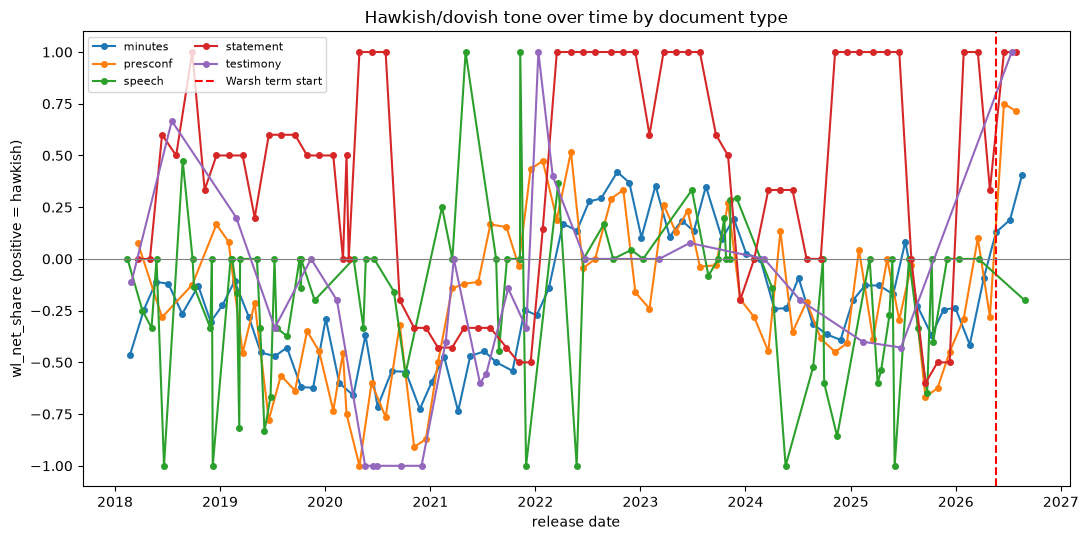

In [5]:
tone_col = "wl_net_share"   # or "fb_sim_net", "fb_pos"

fig, ax = plt.subplots(figsize=(11, 5.5))
for kind, grp in scored.groupby("kind"):
    ax.plot(grp["date"], grp[tone_col], marker="o", ls="-", ms=4, label=kind)
ax.axvline(pd.Timestamp(WARSH_START), color="r", ls="--", lw=1.5, label="Warsh term start")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("release date")
ax.set_ylabel(f"{tone_col} (positive = hawkish)")
ax.set_title("Hawkish/dovish tone over time by document type")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "figure1_tone_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Market reaction and validation (Step 3)

For each release we compute the **one-day change** in the four indicators (`post_close − prev_close`), then regress each on each tone score, controlling for the **3-month Treasury bill** change (`DGS3MO`) so the words are not credited with the rate decision itself.

In [6]:
fred = download_fred()
yahoo = download_yahoo()

TONE_COLS = ["wl_net_share", "wl_net_per_100w", "fb_sim_net", "fb_pos"]
tone_cols = [c for c in TONE_COLS if c in scored.columns]

event = one_day_change(fred, yahoo, scored.set_index("doc_id")["date"])
event = event.join(scored.set_index("doc_id")[["kind", "chair"] + tone_cols])
event.to_csv(SCORE_DIR / "event_changes.csv", index=False)
event[["release", "dxy_chg", "t10y2y_chg", "dgs1_chg", "gv_chg"]].tail()

,release,dxy_chg,t10y2y_chg,dgs1_chg,gv_chg
doc_id,,,,,
testimony_20260714_0830_307,2026-07-14 08:30:00,-0.335699,0.04,-0.10,1.430698
presconf_20260729_1400_308,2026-07-29 14:00:00,-0.572099,0.10,-0.05,-0.966212
statement_20260729_1400_309,2026-07-29 14:00:00,-0.572099,0.10,-0.05,-0.966212
minutes_20260819_1400_310,2026-08-19 14:00:00,-0.822880,-0.06,0.01,-0.841840
speech_20260828_1000_311,2026-08-28 10:00:00,0.544568,-0.08,0.11,-0.208234


### Table 2 — one-day change in the four indicators after each Warsh-era release

In [7]:
warsh_events = event[event.chair == "Warsh"].sort_values("release")
cols = ["release", "kind"] + tone_cols + ["dxy_chg", "t10y2y_chg", "dgs1_chg", "gv_chg", "dgs3mo_chg"]
table2 = warsh_events[cols].round(4)
table2.to_csv(OUTPUT_DIR / "table2_warsh_one_day_changes.csv", index=False)
table2

,release,kind,wl_net_share,wl_net_per_100w,fb_sim_net,fb_pos,dxy_chg,t10y2y_chg,dgs1_chg,gv_chg,dgs3mo_chg
doc_id,,,,,,,,,,,
statement_20260617_1400_304,2026-06-17 14:00:00,statement,1.0000,1.4286,-0.0101,0.5569,0.5525,-0.09,0.14,-0.2578,0.04
presconf_20260617_1400_305,2026-06-17 14:00:00,presconf,0.7500,0.1681,-0.0134,0.1316,0.5525,-0.09,0.14,-0.2578,0.04
minutes_20260708_1400_306,2026-07-08 14:00:00,minutes,0.1892,0.1340,0.0050,0.3375,-0.0890,-0.01,0.00,1.5063,0.01
testimony_20260714_0830_307,2026-07-14 08:30:00,testimony,1.0000,0.1495,-0.0123,0.2642,-0.3357,0.04,-0.10,1.4307,-0.05
presconf_20260729_1400_308,2026-07-29 14:00:00,presconf,0.7143,0.1427,-0.0103,0.1422,-0.5721,0.10,-0.05,-0.9662,-0.07
statement_20260729_1400_309,2026-07-29 14:00:00,statement,1.0000,1.7045,-0.0105,0.4201,-0.5721,0.10,-0.05,-0.9662,-0.07
minutes_20260819_1400_310,2026-08-19 14:00:00,minutes,0.4074,0.1925,0.0043,0.3398,-0.8229,-0.06,0.01,-0.8418,0.00
speech_20260828_1000_311,2026-08-28 10:00:00,speech,-0.2000,-0.0223,-0.0112,0.1714,0.5446,-0.08,0.11,-0.2082,0.06


### Table 3 — each indicator's one-day change regressed on each tone score (3M-bill control)

In [8]:
regs = run_regressions(event, tone_cols)
regs.to_csv(OUTPUT_DIR / "table3_regressions.csv", index=False)
regs.round(4)

,indicator,tone,coef,se,tstat,pvalue,r2,n,control_coef
0,dxy_chg,wl_net_share,-0.0449,0.0505,-0.8884,0.3751,0.0869,293,4.3144
1,dxy_chg,wl_net_per_100w,-0.0892,0.0626,-1.4239,0.1556,0.0908,293,4.3000
2,dxy_chg,fb_sim_net,-1.4310,3.6568,-0.3913,0.6959,0.0849,293,4.3518
3,dxy_chg,fb_pos,0.4910,0.3128,1.5695,0.1176,0.0921,293,4.1645
4,t10y2y_chg,wl_net_share,-0.0113,0.0046,-2.4253,0.0159,0.1493,293,-0.5310
5,t10y2y_chg,wl_net_per_100w,-0.0106,0.0058,-1.8385,0.0670,0.1420,293,-0.5265
6,t10y2y_chg,fb_sim_net,-0.0136,0.3389,-0.0402,0.9679,0.1320,293,-0.5192
7,t10y2y_chg,fb_pos,0.0258,0.0291,0.8873,0.3757,0.1344,293,-0.5294
8,dgs1_chg,wl_net_share,0.0018,0.0051,0.3606,0.7187,0.3105,293,0.9749
9,dgs1_chg,wl_net_per_100w,0.0016,0.0063,0.2474,0.8048,0.3103,293,0.9740


## 4. Forecast of the September 2026 FOMC meeting

Combine the trend (Step 2) and the validated market reaction (Step 3) into explicit probabilities. The numbers below are **your judgment**, grounded in the tables above — fill them in, then re-run this cell.

In [9]:
# Rate decision probabilities -- MUST sum to 100%.  Anchored to market pricing
# (fed funds futures ~72-90% hike, 11 Sep) plus the hawkish tone evidence.
p_cut, p_hold, p_hike = 0.05, 0.25, 0.70
assert abs((p_cut + p_hold + p_hike) - 1.0) < 1e-9, "probabilities must sum to 1"

# Statement tone: probability the September statement is more hawkish than July's.
p_more_hawkish = 0.45

# Market reaction: for each indicator, P(rises on statement day) and expected size.
market_forecast = {
    "DXY":          {"p_rise": 0.65, "size": 0.40},
    "10s2s":        {"p_rise": 0.30, "size": -0.05},
    "1Y yield":     {"p_rise": 0.70, "size": 0.10},
    "Growth-Value": {"p_rise": 0.55, "size": 0.30},
}

## Recommendation

> **Write-up (your own words):** one position you would take ahead of the meeting, why your analysis (Steps 2–3) supports it, and the specific outcome that would prove you wrong.

## Comparison with the readings

> **Write-up:** how your methods and results compare with Doh–Kim–Yang (2021), Doh–Song–Yang (2020), and "Parsing the Fed". Note in particular that the alternative-statements method (Alt A/C/D) is unavailable for the recent sample (5-year release lag), which is why this notebook uses the word list + FinBERT instead.